# 01 Data Loading and Cleaning

**Project:** STAT GR5243 Project 4: End-to-End Machine Learning  
**Topic:** Predicting High-Occupancy Airbnb Listings in New York City

This notebook loads the raw Inside Airbnb NYC data, performs comprehensive data quality analysis, creates the target variable, engineers new features from underutilized columns, handles outliers, and saves a processed dataset for EDA and modeling.

Every column drop is justified with a supporting table or chart.

## 1. Import Libraries and Define Paths

In [1]:
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import KNNImputer

raw_path = Path("../data/raw")
processed_path = Path("../data/processed")
fig_path = Path("../figures")
processed_path.mkdir(parents=True, exist_ok=True)
fig_path.mkdir(parents=True, exist_ok=True)

## 2. Load Raw Data

In [2]:
# Load detailed listings data
listings = pd.read_csv(raw_path / "listings.csv.gz", compression="gzip", low_memory=False)

# Load summary listings data
summary = pd.read_csv(raw_path / "listings.csv", low_memory=False)

# Load neighbourhood data
neighbourhoods = pd.read_csv(raw_path / "neighbourhoods.csv")

print("Detailed listings shape:", listings.shape)
print("Summary listings shape:", summary.shape)
print("Neighbourhoods shape:", neighbourhoods.shape)


Detailed listings shape: (36445, 85)
Summary listings shape: (36445, 19)
Neighbourhoods shape: (230, 2)


## 3. Initial Data Quality Check

The original idea was to predict listing price. However, in the downloaded NYC data, the `price` column is fully missing in both the detailed and summary listings files. Therefore, we shift the project to predicting high-occupancy listings using `estimated_occupancy_l365d`, which is available and complete.


In [3]:
# Check price availability
print("Detailed price missing rate:", listings["price"].isna().mean())
print("Summary price missing rate:", summary["price"].isna().mean())

# Check occupancy variable
print(listings["estimated_occupancy_l365d"].describe())
print(listings["estimated_occupancy_l365d"].value_counts(dropna=False).head(10))


Detailed price missing rate: 1.0
Summary price missing rate: 1.0
count    36445.000000
mean        45.270051
std         83.548761
min          0.000000
25%          0.000000
50%          0.000000
75%         60.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64
estimated_occupancy_l365d
0      25703
255     3028
60      2667
120     1539
180     1050
240      596
13       237
26       155
38       118
51       101
Name: count, dtype: int64


## 4. Define Modeling Target

We define a binary classification target:

- `high_occupancy = 1` if `estimated_occupancy_l365d >= 60`
- `high_occupancy = 0` otherwise

The value 60 corresponds roughly to the upper quartile of the occupancy distribution, which separates more active listings from lower-activity listings.


In [4]:
# Create target variable
listings["high_occupancy"] = (listings["estimated_occupancy_l365d"] >= 60).astype(int)

print(listings["high_occupancy"].value_counts())
print(listings["high_occupancy"].value_counts(normalize=True))


high_occupancy
0    26328
1    10117
Name: count, dtype: int64
high_occupancy
0    0.722404
1    0.277596
Name: proportion, dtype: float64


## 5. Missing Value Summary

Before selecting variables, we examine missingness across all 85 raw columns. This lets us make informed decisions about which columns to keep, drop, or treat specially.

In [5]:
# Missing value summary for all columns
missing_summary = pd.DataFrame({
    "column": listings.columns,
    "missing_count": listings.isnull().sum().values,
    "missing_pct": (listings.isnull().mean() * 100).round(1).values,
    "dtype": listings.dtypes.astype(str).values,
    "n_unique": listings.nunique().values
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

print(f"Total columns: {len(missing_summary)}")
print(f"Columns 100% missing: {(missing_summary['missing_pct'] == 100.0).sum()}")
print(f"Columns with any missing: {(missing_summary['missing_pct'] > 0).sum()}")
print()
missing_summary.head(30)

Total columns: 86
Columns 100% missing: 14
Columns with any missing: 51



,column,missing_count,missing_pct,dtype,n_unique
0,host_verifications,36445,100.0,float64,0
1,instant_bookable,36445,100.0,float64,0
2,host_neighbourhood,36445,100.0,float64,0
3,host_thumbnail_url,36445,100.0,float64,0
4,host_acceptance_rate,36445,100.0,float64,0
5,host_response_rate,36445,100.0,float64,0
6,host_response_time,36445,100.0,float64,0
7,host_total_listings_count,36445,100.0,float64,0
8,host_since,36445,100.0,float64,0
9,neighbourhood,36445,100.0,float64,0


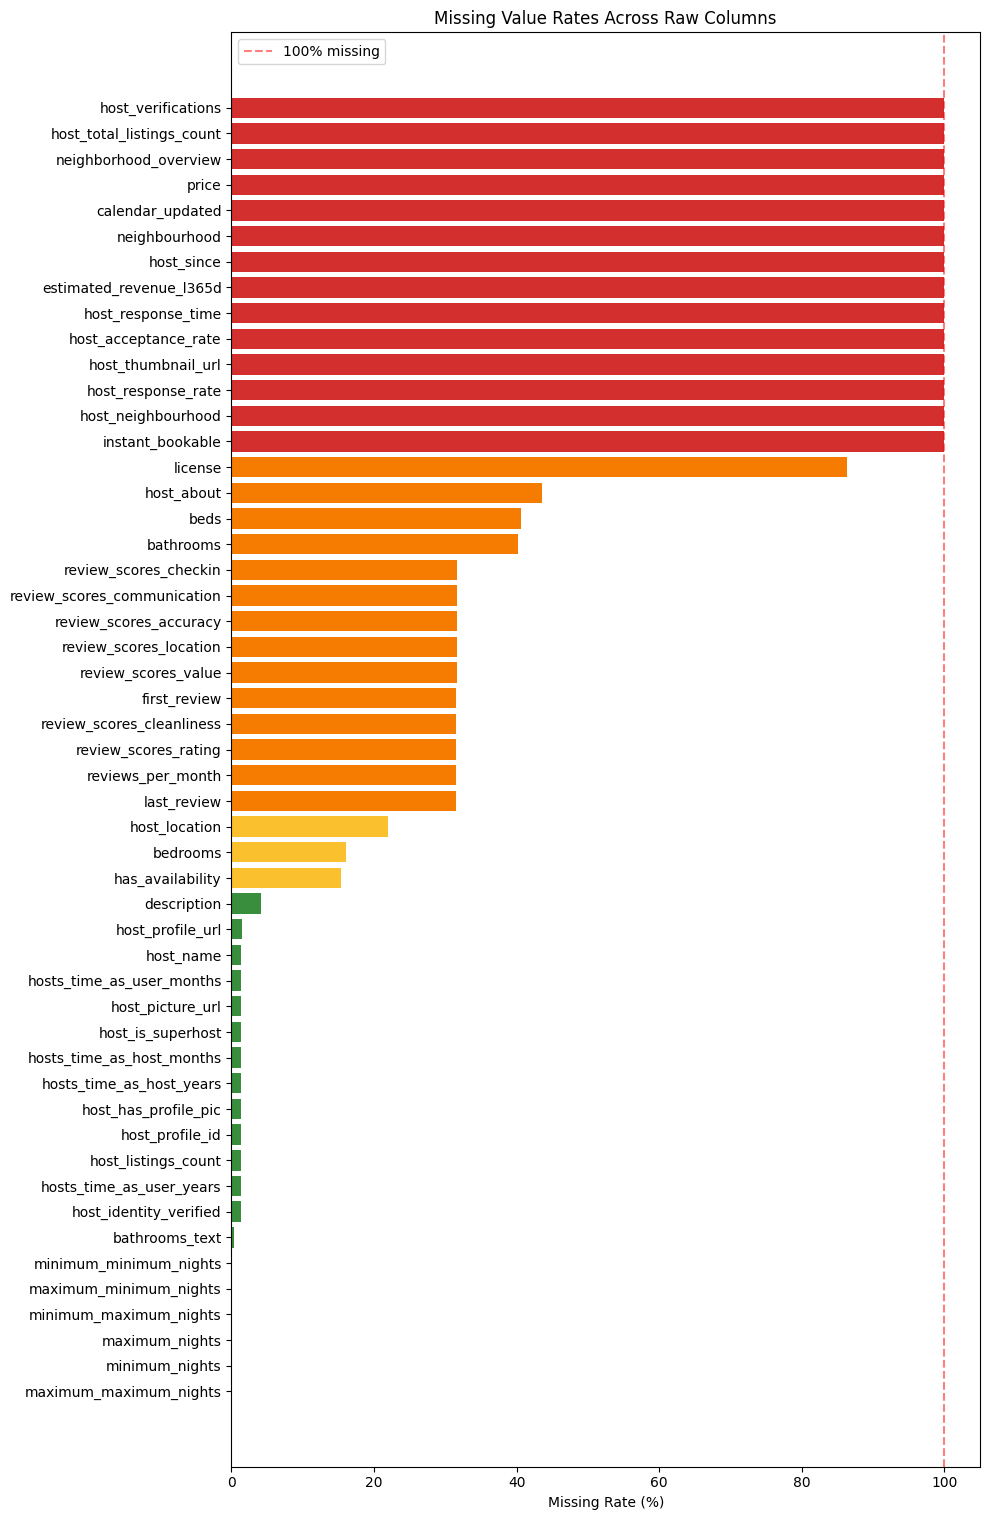

In [6]:
# Bar chart of missing value rates for columns with any missingness
cols_with_missing = missing_summary[missing_summary["missing_pct"] > 0].sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(10, max(6, len(cols_with_missing) * 0.3)))
colors = []
for pct in cols_with_missing["missing_pct"]:
    if pct >= 99:
        colors.append("#d32f2f")
    elif pct >= 30:
        colors.append("#f57c00")
    elif pct >= 5:
        colors.append("#fbc02d")
    else:
        colors.append("#388e3c")

ax.barh(cols_with_missing["column"], cols_with_missing["missing_pct"], color=colors)
ax.set_xlabel("Missing Rate (%)")
ax.set_title("Missing Value Rates Across Raw Columns")
ax.axvline(x=100, color="red", linestyle="--", alpha=0.5, label="100% missing")
ax.legend()
plt.tight_layout()
plt.savefig(fig_path / "00a_missing_value_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Identify and Drop 100%-Missing Columns

14 columns are completely missing in this dataset snapshot. Among them, 6 were previously included in the selected variable list. After imputation, these become constant-valued columns with zero variance -- they cannot help any model.

We verify this below: if we were to impute them (median for numeric, "Unknown" for categorical), every row gets the same value.

In [7]:
# Justification table: what happens if we impute these 100%-missing columns
previously_selected_dead = [
    "host_response_rate", "host_acceptance_rate", "host_response_time",
    "host_since", "host_total_listings_count", "instant_bookable"
]

proof_rows = []
for col in previously_selected_dead:
    dtype = str(listings[col].dtype)
    if dtype in ("float64", "int64"):
        imputed_val = 0.0
    else:
        imputed_val = "Unknown"
    proof_rows.append({
        "column": col,
        "raw_missing_pct": "100.0%",
        "dtype": dtype,
        "imputed_value": imputed_val,
        "n_unique_after_impute": 1,
        "verdict": "DROP: zero variance"
    })

proof_df = pd.DataFrame(proof_rows)
print("Previously selected columns that are 100% missing in raw data:\n")
proof_df

Previously selected columns that are 100% missing in raw data:



,column,raw_missing_pct,dtype,imputed_value,n_unique_after_impute,verdict
0,host_response_rate,100.0%,float64,0.0,1,DROP: zero variance
1,host_acceptance_rate,100.0%,float64,0.0,1,DROP: zero variance
2,host_response_time,100.0%,float64,0.0,1,DROP: zero variance
3,host_since,100.0%,float64,0.0,1,DROP: zero variance
4,host_total_listings_count,100.0%,float64,0.0,1,DROP: zero variance
5,instant_bookable,100.0%,float64,0.0,1,DROP: zero variance


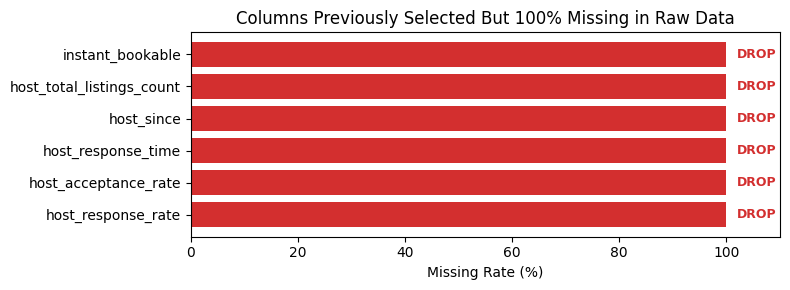

In [8]:
# Visual: these 6 columns vs dataset average
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(previously_selected_dead, [100]*6, color="#d32f2f")
ax.set_xlabel("Missing Rate (%)")
ax.set_title("Columns Previously Selected But 100% Missing in Raw Data")
ax.set_xlim(0, 110)
for i, col in enumerate(previously_selected_dead):
    ax.text(102, i, "DROP", va="center", fontsize=9, fontweight="bold", color="#d32f2f")
plt.tight_layout()
plt.savefig(fig_path / "00b_constant_columns_justification.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Select Useful Variables

We select columns based on three criteria:
1. **Not 100% missing** -- excludes the 6 constant columns identified above
2. **Relevant to predicting occupancy** -- host, property, location, booking, and review features
3. **Not redundant** -- use `bathrooms_text` (0.3% missing) instead of `bathrooms` (40.2% missing)

We also add columns: `amenities`, `description`, `name`, and `host_has_profile_pic`.

**Note:** We intentionally exclude `first_review` and `last_review`. Features derived from these dates (e.g., days since last review) are post-outcome proxies for booking activity and would cause data leakage in modeling.

In [9]:
selected_cols = [
    # Identifiers
    "id", "listing_url",
    # Host characteristics (excluding 100%-missing columns)
    "hosts_time_as_host_years",
    "host_is_superhost",
    "host_listings_count",
    "host_identity_verified",
    "host_has_profile_pic",
    # Location
    "neighbourhood_cleansed", "neighbourhood_group_cleansed",
    "latitude", "longitude",
    # Property details
    "property_type", "room_type",
    "accommodates", "bathrooms_text", "bedrooms", "beds",
    "minimum_nights", "maximum_nights",
    # Availability
    "availability_30", "availability_60", "availability_90",
    "availability_365", "availability_eoy",
    # Reviews
    "number_of_reviews", "number_of_reviews_ltm",
    "number_of_reviews_l30d", "number_of_reviews_ly",
    "reviews_per_month",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    # Calculated host counts
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    # Target
    "estimated_occupancy_l365d", "high_occupancy",
    # New: text and amenities (will be parsed into features then dropped)
    "name", "description", "amenities"
]

available_cols = [col for col in selected_cols if col in listings.columns]
missing_cols = [col for col in selected_cols if col not in listings.columns]
if missing_cols:
    print("WARNING: columns not found in raw data:", missing_cols)

df = listings[available_cols].copy()
print("Selected data shape:", df.shape)

Selected data shape: (36445, 45)


## 8. Parse `bathrooms_text` to Replace `bathrooms`

The raw `bathrooms` column is 40.2% missing, but `bathrooms_text` is only 0.3% missing and contains richer information (number + shared/private distinction). We parse it into:
- `bathrooms_count` (float): the numeric bathroom count
- `bathroom_is_shared` (0/1): whether the bathroom is shared

In [10]:
# Justification: compare bathrooms vs bathrooms_text missing rates
compare_bath = pd.DataFrame({
    "column": ["bathrooms (old)", "bathrooms_text (new source)"],
    "missing_rate": [
        f"{listings['bathrooms'].isna().mean()*100:.1f}%",
        f"{listings['bathrooms_text'].isna().mean()*100:.1f}%"
    ],
    "sample_values": [
        str(listings["bathrooms"].dropna().unique()[:5]),
        str(listings["bathrooms_text"].dropna().unique()[:5])
    ]
})
print("Justification for replacing bathrooms with parsed bathrooms_text:\n")
compare_bath

Justification for replacing bathrooms with parsed bathrooms_text:



,column,missing_rate,sample_values
0,bathrooms (old),40.2%,[1. 1.5 2. 2.5 3. ]
1,bathrooms_text (new source),0.3%,"<StringArray>\n['1 bath', '1 shared bath', '1 ..."


In [11]:
# Parse bathrooms_text into bathrooms_count and bathroom_is_shared
def parse_bathrooms_text(text):
    if pd.isna(text):
        return np.nan, np.nan
    text_lower = text.lower().strip()
    is_shared = 1 if "shared" in text_lower else 0
    if "half" in text_lower:
        count = 0.5
    else:
        match = re.match(r"([\d.]+)", text_lower)
        count = float(match.group(1)) if match else np.nan
    return count, is_shared

parsed = df["bathrooms_text"].apply(parse_bathrooms_text)
df["bathrooms_count"] = parsed.apply(lambda x: x[0])
df["bathroom_is_shared"] = parsed.apply(lambda x: x[1])
df.drop(columns=["bathrooms_text"], inplace=True)

print("bathrooms_count stats:")
print(df["bathrooms_count"].describe())
print(f"\nbathrooms_count missing: {df['bathrooms_count'].isna().sum()} ({df['bathrooms_count'].isna().mean()*100:.1f}%)")
print(f"\nbathroom_is_shared distribution:")
print(df["bathroom_is_shared"].value_counts(dropna=False))

bathrooms_count stats:
count    36341.000000
mean         1.170675
std          0.490587
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.500000
Name: bathrooms_count, dtype: float64

bathrooms_count missing: 104 (0.3%)

bathroom_is_shared distribution:
bathroom_is_shared
0.0    26743
1.0     9598
NaN      104
Name: count, dtype: int64


## 9. Parse Amenities

The `amenities` column (0% missing) contains JSON arrays of amenity names. We extract:
- `amenity_count`: total number of amenities
- Binary flags for key amenities plausibly related to occupancy: wifi, air conditioning, kitchen, washer

In [12]:
# Parse amenities JSON into features
def parse_amenities(amenity_str):
    try:
        items = json.loads(amenity_str)
        items_lower = [item.lower() for item in items]
    except (json.JSONDecodeError, TypeError):
        return {"amenity_count": 0, "has_wifi": 0, "has_ac": 0, "has_kitchen": 0, "has_washer": 0}
    return {
        "amenity_count": len(items),
        "has_wifi": int(any("wifi" in a for a in items_lower)),
        "has_ac": int(any("air conditioning" in a or "central air" in a for a in items_lower)),
        "has_kitchen": int(any("kitchen" in a for a in items_lower)),
        "has_washer": int(any("washer" in a for a in items_lower)),
    }

amenity_features = df["amenities"].apply(parse_amenities).apply(pd.Series)
df = pd.concat([df, amenity_features], axis=1)
df.drop(columns=["amenities"], inplace=True)

# Summary
print("Amenity features summary:\n")
print(f"amenity_count: mean={df['amenity_count'].mean():.1f}, median={df['amenity_count'].median():.0f}, max={df['amenity_count'].max()}")
for col in ["has_wifi", "has_ac", "has_kitchen", "has_washer"]:
    print(f"{col}: {df[col].sum()} listings ({df[col].mean()*100:.1f}%)")

Amenity features summary:

amenity_count: mean=26.0, median=24, max=90
has_wifi: 35634 listings (97.8%)
has_ac: 27863 listings (76.5%)
has_kitchen: 32145 listings (88.2%)
has_washer: 18358 listings (50.4%)


## 10. Extract Text Length Features

Listing titles and descriptions vary in length. Longer, more detailed descriptions may signal host effort, which could correlate with occupancy. We extract character counts as simple numeric proxies, then drop the raw text columns.

In [13]:
# Extract text length features
df["name_length"] = df["name"].fillna("").str.len()
df["description_length"] = df["description"].fillna("").str.len()
df.drop(columns=["name", "description"], inplace=True)

print("name_length:", df["name_length"].describe().to_dict())
print("description_length:", df["description_length"].describe().to_dict())

name_length: {'count': 36445.0, 'mean': 37.00828645904788, 'std': 10.652846494951206, 'min': 0.0, '25%': 30.0, '50%': 38.0, '75%': 47.0, 'max': 154.0}
description_length: {'count': 36445.0, 'mean': 340.36389079434764, 'std': 157.2364984120772, 'min': 0.0, '25%': 237.0, '50%': 373.0, '75%': 484.0, 'max': 1000.0}


## 11. Convert Binary Variables

Convert true/false string columns to binary 0/1 indicators, including the newly added `host_has_profile_pic` trust signal (1.4% missing).

In [14]:
# Convert t/f binary columns to 0/1
binary_cols = ["host_is_superhost", "host_identity_verified", "host_has_profile_pic"]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({"t": 1, "f": 0})
        print(f"{col}: {df[col].value_counts(dropna=False).to_dict()}")

host_is_superhost: {0.0: 28928, 1.0: 6989, nan: 528}
host_identity_verified: {1.0: 33989, 0.0: 1928, nan: 528}
host_has_profile_pic: {1.0: 34854, 0.0: 1063, nan: 528}


## 12. Outlier Capping

Two columns have extreme outliers:
- `minimum_nights`: max = 1,124 while the 99th percentile is 90
- `maximum_nights`: max = 2,147,483,648 (likely an integer overflow artifact) while the 99th percentile is 1,125

We cap both at their 99th percentile values to prevent extreme values from distorting model training.


minimum_nights BEFORE capping:
  min=0.0, max=1124.0, mean=28.2, 99th=90.0
  AFTER: min=0.0, max=90.0, mean=26.8
  Rows capped: 285

maximum_nights BEFORE capping:
  min=1.0, max=2147483647.0, mean=1062085.7, 99th=1125.0
  AFTER: min=1.0, max=1125.0, mean=667.4
  Rows capped: 27


/var/folders/pt/24j55gbs1sb2hvwm833zm9cm0000gn/T/ipykernel_79360/542135506.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([df[col].dropna(), df[col].clip(upper=cap_value).dropna()],
/var/folders/pt/24j55gbs1sb2hvwm833zm9cm0000gn/T/ipykernel_79360/542135506.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([df[col].dropna(), df[col].clip(upper=cap_value).dropna()],


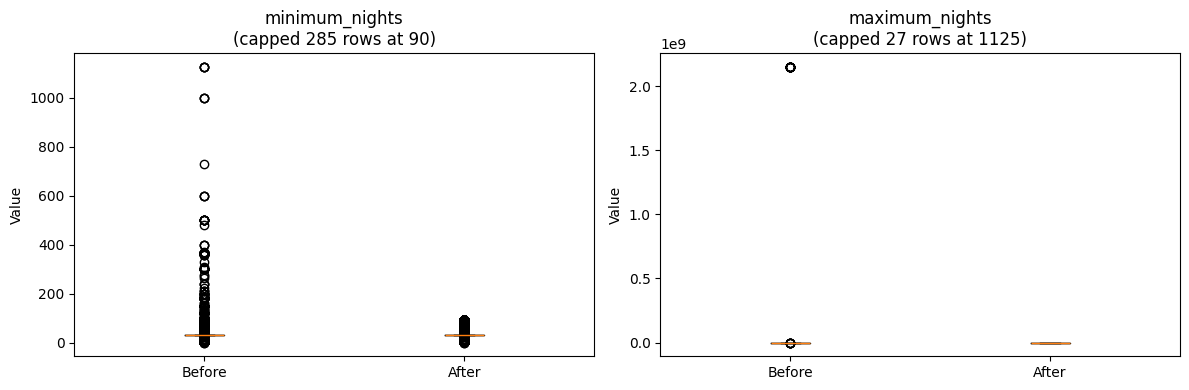

In [15]:
# Before/after outlier capping
cap_cols = ["minimum_nights", "maximum_nights"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(cap_cols):
    cap_value = df[col].quantile(0.99)
    n_capped = (df[col] > cap_value).sum()

    # Before stats
    print(f"\n{col} BEFORE capping:")
    print(f"  min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.1f}, 99th={cap_value}")

    # Box plot before
    axes[i].boxplot([df[col].dropna(), df[col].clip(upper=cap_value).dropna()],
                    labels=["Before", "After"], vert=True)
    axes[i].set_title(f"{col}\n(capped {n_capped} rows at {cap_value:.0f})")
    axes[i].set_ylabel("Value")

    # Apply cap
    df[col] = df[col].clip(upper=cap_value)
    print(f"  AFTER: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.1f}")
    print(f"  Rows capped: {n_capped}")

plt.tight_layout()
plt.savefig(fig_path / "00d_outlier_capping.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Impute Missing Values

We use **KNN imputation** (k=5) for numeric and binary columns. KNN finds the 5 most similar listings based on non-missing features and averages their values, producing more realistic imputations than a global median — especially for correlated features like `bedrooms`, `beds`, and `bathrooms_count`.

**Imputation strategy:**
- `reviews_per_month`: fill with 0 (domain logic: no reviews = 0 reviews/month)
- Review scores: create missing indicators first, then include in KNN imputation
- All other numeric and binary columns: KNN imputation (k=5)
- Categorical columns: fill with "Unknown"
- Binary columns are rounded to 0/1 after KNN to preserve their discrete nature

In [16]:
# Record pre-imputation state for the summary
pre_impute_missing = df.isna().sum().sum()
pre_impute_cols_missing = (df.isna().sum() > 0).sum()

# 1. Domain-specific fill: reviews_per_month = 0 when no reviews
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# 2. Review scores: create missing indicators before imputation
review_cols = [
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value"
]

for col in review_cols:
    if col in df.columns:
        df[col + "_missing"] = df[col].isna().astype(int)

# 3. Fill categorical columns with "Unknown" (KNN cannot handle these)
categorical_cols = [
    "neighbourhood_cleansed", "neighbourhood_group_cleansed",
    "property_type", "room_type"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 4. Drop rows missing essential fields before KNN
df = df.dropna(subset=["estimated_occupancy_l365d", "latitude", "longitude"])

# 5. KNN imputation on all numeric columns with missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude identifiers and target from KNN feature matrix
knn_exclude = ["id", "estimated_occupancy_l365d", "high_occupancy"]
knn_cols = [c for c in numeric_cols if c not in knn_exclude]

print(f"KNN imputation on {len(knn_cols)} numeric columns (k=5)...")
cols_with_na = [c for c in knn_cols if df[c].isna().any()]
print(f"  Columns with missing values: {cols_with_na}")
print(f"  Missing counts: { {c: int(df[c].isna().sum()) for c in cols_with_na} }")

knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")
df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

# 6. Round binary columns back to 0/1 after KNN averaging
binary_cols = [
    "host_is_superhost", "host_identity_verified", "host_has_profile_pic",
    "bathroom_is_shared", "has_wifi", "has_ac", "has_kitchen", "has_washer"
] + [col + "_missing" for col in review_cols]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].round().astype(int)

print(f"\nPre-imputation: {pre_impute_missing} missing values across {pre_impute_cols_missing} columns")
print(f"Post-imputation: {df.isna().sum().sum()} missing values")
print(f"Final shape: {df.shape}")

KNN imputation on 49 numeric columns (k=5)...
  Columns with missing values: ['hosts_time_as_host_years', 'host_is_superhost', 'host_listings_count', 'host_identity_verified', 'host_has_profile_pic', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'bathrooms_count', 'bathroom_is_shared']
  Missing counts: {'hosts_time_as_host_years': 528, 'host_is_superhost': 528, 'host_listings_count': 528, 'host_identity_verified': 528, 'host_has_profile_pic': 528, 'bedrooms': 5877, 'beds': 14792, 'minimum_nights': 27, 'maximum_nights': 27, 'review_scores_rating': 11496, 'review_scores_accuracy': 11506, 'review_scores_cleanliness': 11497, 'review_scores_checkin': 11510, 'review_scores_communication': 11502, 'review_scores_location': 11513, 'review_scores_value': 11512, 'bathrooms_count': 104, 'bathroom_is_shared


Pre-imputation: 115603 missing values across 19 columns
Post-imputation: 0 missing values
Final shape: (36445, 57)


## 14. Data Quality Summary

We compare the dataset before and after cleaning to document the transformations applied.

In [17]:
# Before vs after comparison
summary_table = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Total missing values",
               "Columns with any missing", "100%-missing columns"],
    "Before (raw)": [
        listings.shape[0], listings.shape[1],
        int(listings.isna().sum().sum()),
        int((listings.isna().sum() > 0).sum()),
        int((listings.isna().mean() >= 0.999).sum())
    ],
    "After (cleaned)": [
        df.shape[0], df.shape[1],
        int(df.isna().sum().sum()),
        int((df.isna().sum() > 0).sum()),
        int((df.isna().mean() >= 0.999).sum())
    ]
})

print("Data Quality: Before vs After Cleaning\n")
summary_table

Data Quality: Before vs After Cleaning



,Metric,Before (raw),After (cleaned)
0,Rows,36445,36445
1,Columns,86,57
2,Total missing values,729543,0
3,Columns with any missing,52,0
4,100%-missing columns,14,0


In [18]:
# Final column overview
final_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "n_unique": df.nunique().values
}).reset_index(drop=True)

print(f"Final cleaned dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Zero missing values confirmed: {df.isna().sum().sum() == 0}\n")
final_overview

Final cleaned dataset: 36445 rows x 57 columns
Zero missing values confirmed: True



,column,dtype,missing,n_unique
0,id,int64,0,36445
1,listing_url,str,0,36445
2,hosts_time_as_host_years,float64,0,40
3,host_is_superhost,int64,0,2
4,host_listings_count,float64,0,147
5,host_identity_verified,int64,0,2
6,host_has_profile_pic,int64,0,2
7,neighbourhood_cleansed,str,0,224
8,neighbourhood_group_cleansed,str,0,5
9,latitude,float64,0,22422


## 15. Save Processed Dataset

In [19]:
output_file = processed_path / "nyc_airbnb_cleaned.csv"
df.to_csv(output_file, index=False)

print("Saved cleaned dataset to:", output_file)
print("Shape:", df.shape)
df.head()

Saved cleaned dataset to: ../data/processed/nyc_airbnb_cleaned.csv
Shape: (36445, 57)


,id,listing_url,hosts_time_as_host_years,host_is_superhost,host_listings_count,host_identity_verified,host_has_profile_pic,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,...,has_washer,name_length,description_length,review_scores_rating_missing,review_scores_accuracy_missing,review_scores_cleanliness_missing,review_scores_checkin_missing,review_scores_communication_missing,review_scores_location_missing,review_scores_value_missing
0,2595,https://www.airbnb.com/rooms/2595,15.0,0,7.0,1,1,Midtown,Manhattan,40.75356,...,0,49.0,510.0,0,0,0,0,0,0,0
1,6848,https://www.airbnb.com/rooms/6848,15.0,1,1.0,1,1,Williamsburg,Brooklyn,40.70935,...,1,32.0,140.0,0,0,0,0,0,0,0
2,6872,https://www.airbnb.com/rooms/6872,15.0,0,2.0,1,1,East Harlem,Manhattan,40.80107,...,1,49.0,514.0,0,0,0,0,0,0,0
3,6990,https://www.airbnb.com/rooms/6990,15.0,1,1.0,1,1,East Harlem,Manhattan,40.78778,...,0,23.0,31.0,0,0,0,0,0,0,0
4,7097,https://www.airbnb.com/rooms/7097,15.0,1,2.0,1,1,Fort Greene,Brooklyn,40.69194,...,1,45.0,459.0,0,0,0,0,0,0,0


## 16. Cleaning Summary

Key cleaning decisions and enhancements:

1. **Price column unavailable**: The `price` column is 100% missing; we pivoted to predicting occupancy.
2. **Target variable**: `high_occupancy = 1` if `estimated_occupancy_l365d >= 60`.
3. **6 constant columns dropped**: `host_response_rate`, `host_acceptance_rate`, `host_response_time`, `host_since`, `host_total_listings_count`, and `instant_bookable` were all 100% missing in the raw data. Justified with table and chart in Sections 5-6.
4. **`bathrooms` replaced**: Parsed `bathrooms_text` (0.3% missing) into `bathrooms_count` and `bathroom_is_shared`, replacing `bathrooms` (40.2% missing). Justified with comparison table in Section 8.
5. **Amenities parsed**: Extracted `amenity_count` and 4 binary flags (`has_wifi`, `has_ac`, `has_kitchen`, `has_washer`) from the JSON `amenities` column (0% missing).
6. **Text length features**: Extracted `name_length` and `description_length` from listing title and description.
7. **Date features excluded**: `first_review` and `last_review` are intentionally excluded because derived features (e.g., days since last review) are post-outcome proxies for booking activity, causing data leakage.
8. **Trust signal added**: `host_has_profile_pic` converted from t/f to 0/1.
9. **Outliers capped**: `minimum_nights` and `maximum_nights` capped at 99th percentile. Justified with before/after box plots in Section 12.
10. **Binary t/f to 0/1**: `host_is_superhost`, `host_identity_verified`, `host_has_profile_pic`.
11. **Review scores**: Missing indicators created before imputation.
12. **KNN imputation (k=5)**: All numeric and binary columns imputed using K-Nearest Neighbors, which leverages inter-feature correlations (e.g., bedrooms/beds/accommodates) for more realistic fill values than a global median. Binary columns rounded to 0/1 after averaging.
13. **Remaining categoricals**: Filled with "Unknown".

The cleaned dataset is saved to `data/processed/nyc_airbnb_cleaned.csv` and is ready for EDA, unsupervised learning, feature engineering, and supervised classification modeling.